In [ ]:
import numpy
import pandas
import matplotlib.pyplot as plt
import tensorflow as tf

print("All libraries imported successfully")

All libraries imported successfully


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout

from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Keras libraries imported successfully")

Keras libraries imported successfully


In [ ]:
!pip install -q datasets

In [ ]:
from datasets import load_dataset

dataset = load_dataset("geraldmc/plantvillage-tiny")

print(dataset)

README.md:   0%|          | 0.00/2.96k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 31.1MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1900 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped'],
        num_rows: 1900
    })
})


In [ ]:
#  Check the dataset

print("Dataset:")
print(dataset)

print("\nDataset columns:")
print(dataset["train"].column_names)

print("\nTotal images:")
print(len(dataset["train"]))

Dataset:
DatasetDict({
    train: Dataset({
        features: ['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped'],
        num_rows: 1900
    })
})

Dataset columns:
['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped']

Total images:
1900


In [ ]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['image', 'class_label', 'class_idx', 'host', 'disease', 'split', 'leaf_id', 'leaf_grouped'],
        num_rows: 1900
    })
})


In [ ]:
#  Get class names

class_names = sorted(set(dataset["train"]["class_label"]))

print("Class Names:")
print(class_names)

Class Names:
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomat

In [ ]:
#  Count total classes

total_classes = len(class_names)

print("Total Classes:", total_classes)

Total Classes: 38


In [ ]:
#  Count images in each class

class_counts = (
    dataset["train"]
    .to_pandas()["class_label"]
    .value_counts()
    .sort_index()
)

print("Images in each class:")
print(class_counts)

Images in each class:
class_label
Apple___Apple_scab                                    50
Apple___Black_rot                                     50
Apple___Cedar_apple_rust                              50
Apple___healthy                                       50
Blueberry___healthy                                   50
Cherry_(including_sour)___Powdery_mildew              50
Cherry_(including_sour)___healthy                     50
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot    50
Corn_(maize)___Common_rust_                           50
Corn_(maize)___Northern_Leaf_Blight                   50
Corn_(maize)___healthy                                50
Grape___Black_rot                                     50
Grape___Esca_(Black_Measles)                          50
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)            50
Grape___healthy                                       50
Orange___Haunglongbing_(Citrus_greening)              50
Peach___Bacterial_spot                                

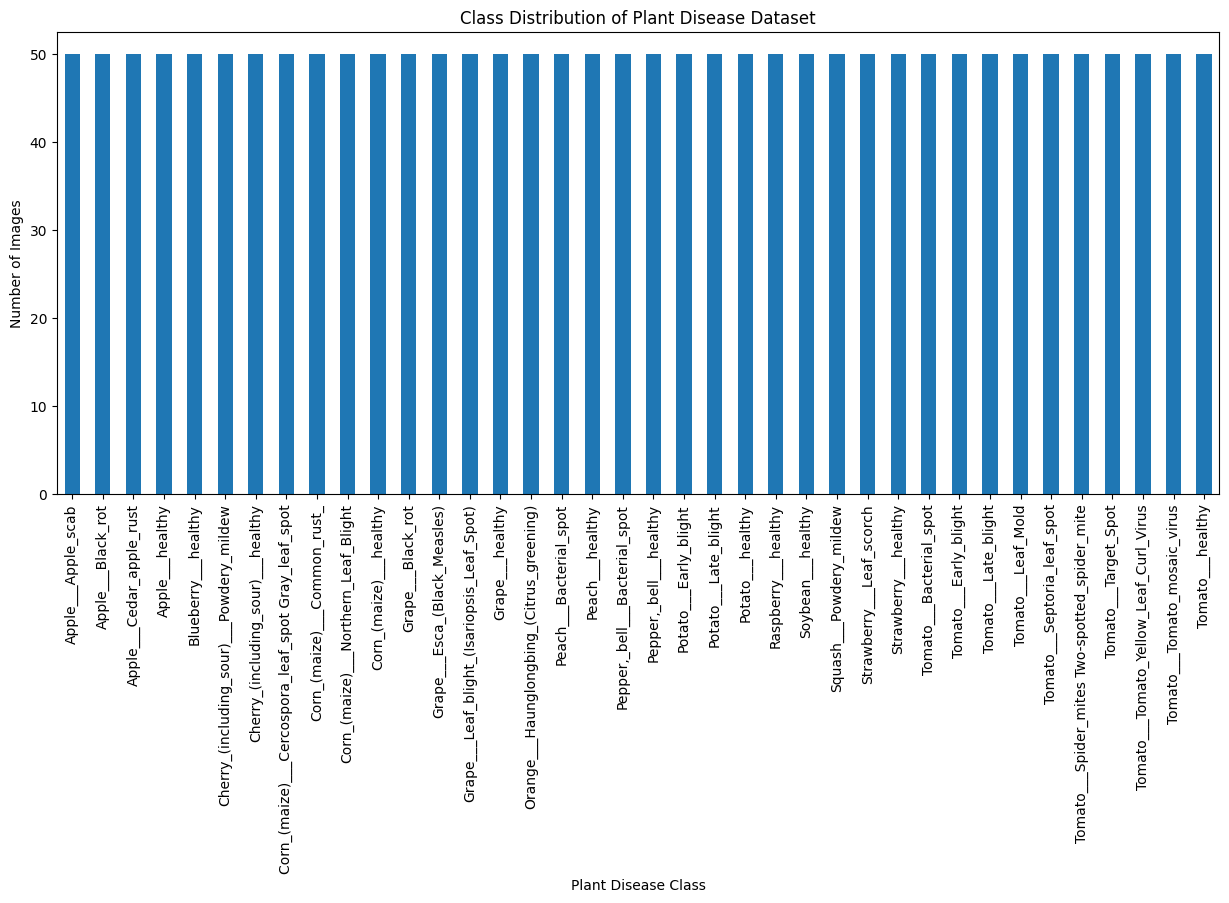

In [ ]:
#  Display class distribution

plt.figure(figsize=(15, 6))

class_counts.plot(kind="bar")

plt.xlabel("Plant Disease Class")
plt.ylabel("Number of Images")
plt.title("Class Distribution of Plant Disease Dataset")

plt.xticks(rotation=90)

plt.show()

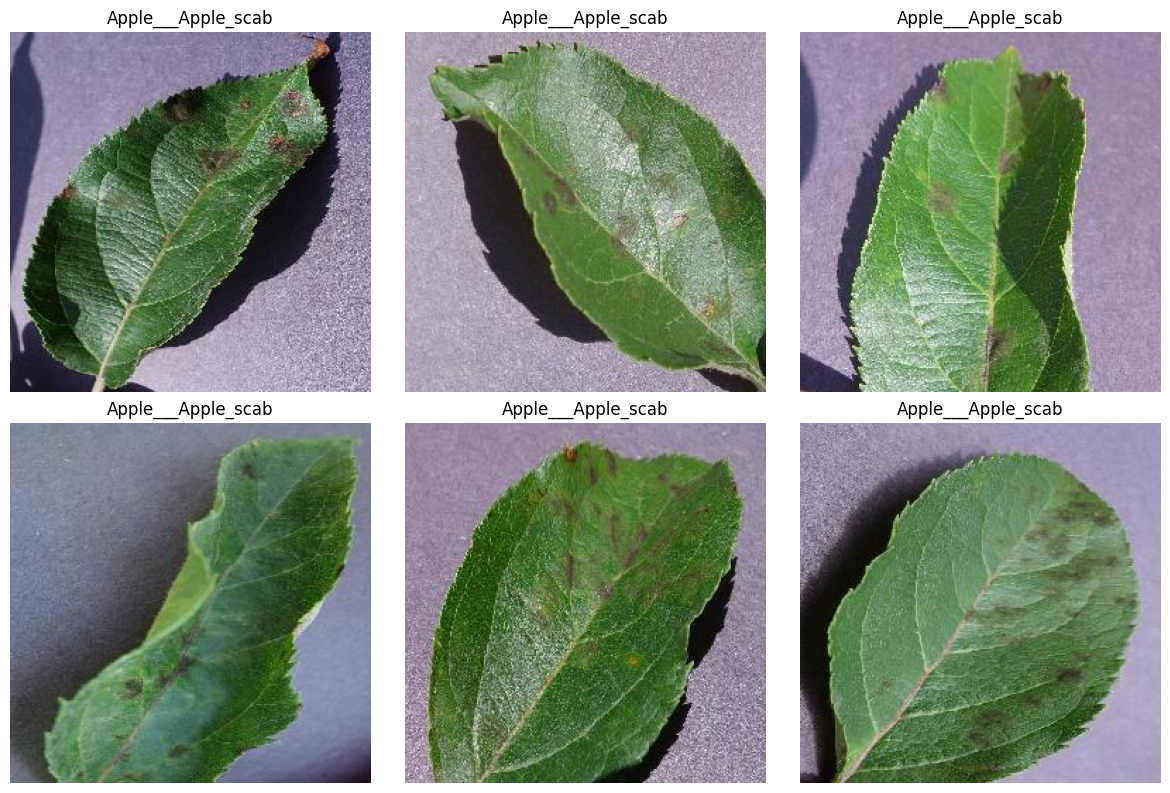

In [ ]:
# Display sample plant images

plt.figure(figsize=(12, 8))

for i in range(6):

    image = dataset["train"][i]["image"]
    label = dataset["train"][i]["class_label"]

    plt.subplot(2, 3, i + 1)

    plt.imshow(image)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Set image size

IMG_SIZE = 128

print("Image Size:", IMG_SIZE, "x", IMG_SIZE)

Image Size: 128 x 128


In [ ]:
#  Convert images into NumPy arrays

X = []
Y = []

for item in dataset["train"]:

    # Get image
    img = item["image"]

    # Resize image
    img = img.resize((IMG_SIZE, IMG_SIZE))

    # Convert image to NumPy array
    img = numpy.array(img)

    # Add image to X
    X.append(img)

    # Add class label to Y
    Y.append(item["class_idx"])

X = numpy.array(X)
Y = numpy.array(Y)

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (1900, 128, 128, 3)
Y shape: (1900,)


In [ ]:
#  Normalize image pixels

X = X.astype("float32") / 255.0

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [ ]:
#  One-hot encode class labels

from tensorflow.keras.utils import to_categorical

Y = to_categorical(Y, num_classes=total_classes)

print("Y shape:", Y.shape)

Y shape: (1900, 38)


In [ ]:
# Split dataset into training and testing data

from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=7,
    stratify=Y
)

print("Training images:", X_train.shape[0])
print("Testing images:", X_test.shape[0])

Training images: 1520
Testing images: 380


In [ ]:
#  Define CNN model

def baseline_model():

    # Create model
    model = Sequential()

    # First convolution layer
    model.add(
        Conv2D(
            32,
            (3, 3),
            activation="relu",
            input_shape=(128, 128, 3)
        )
    )

    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Second convolution layer
    model.add(
        Conv2D(
            64,
            (3, 3),
            activation="relu"
        )
    )

    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Third convolution layer
    model.add(
        Conv2D(
            128,
            (3, 3),
            activation="relu"
        )
    )

    model.add(MaxPooling2D(pool_size=(2, 2)))

    # Convert feature maps into one dimension
    model.add(Flatten())

    # Fully connected layer
    model.add(
        Dense(
            128,
            activation="relu"
        )
    )

    # Dropout
    model.add(Dropout(0.5))

    # Output layer
    model.add(
        Dense(
            total_classes,
            activation="softmax"
        )
    )

    # Compile model
    model.compile(
        loss="categorical_crossentropy",
        optimizer="adam",
        metrics=["accuracy"]
    )

    return model

In [ ]:
#  Create CNN model

model = baseline_model()

print("CNN model created successfully")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


CNN model created successfully


In [ ]:
# Display model summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,309,542 (12.62 MB)

 Trainable params: 3,309,542 (12.62 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#  Train CNN model

history = model.fit(
    X_train,
    Y_train,
    validation_data=(X_test, Y_test),
    epochs=10,
    batch_size=32
)

Epoch 1/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.0362 - loss: 3.6379 - val_accuracy: 0.0947 - val_loss: 3.5075
Epoch 2/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.0928 - loss: 3.3994 - val_accuracy: 0.1684 - val_loss: 3.1800
Epoch 3/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 65s 1s/step - accuracy: 0.1882 - loss: 3.0659 - val_accuracy: 0.2974 - val_loss: 2.7266
Epoch 4/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.2480 - loss: 2.7190 - val_accuracy: 0.3474 - val_loss: 2.4796
Epoch 5/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step - accuracy: 0.3086 - loss: 2.3745 - val_accuracy: 0.4237 - val_loss: 2.1542
Epoch 6/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 68s 1s/step - accuracy: 0.3829 - loss: 2.0749 - val_accuracy: 0.4684 - val_loss: 1.9797
Epoch 7/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.4414 - loss: 1.8742 - val_accuracy: 0.4947 - val_loss: 1.8233
Epoch 8/10
48/48 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.4770 - loss: 1.7487 - val_accuracy: 0.5053 - val_loss:

In [ ]:
#  Evaluate the model

loss, accuracy = model.evaluate(
    X_test,
    Y_test,
    verbose=0
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy * 100, "%")

Test Loss: 1.7320564985275269
Test Accuracy: 50.0 %


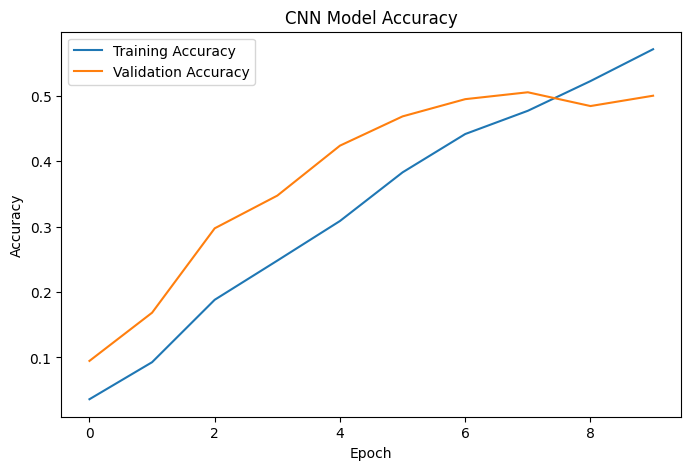

In [ ]:
# Plot accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Model Accuracy")

plt.legend()
plt.show()

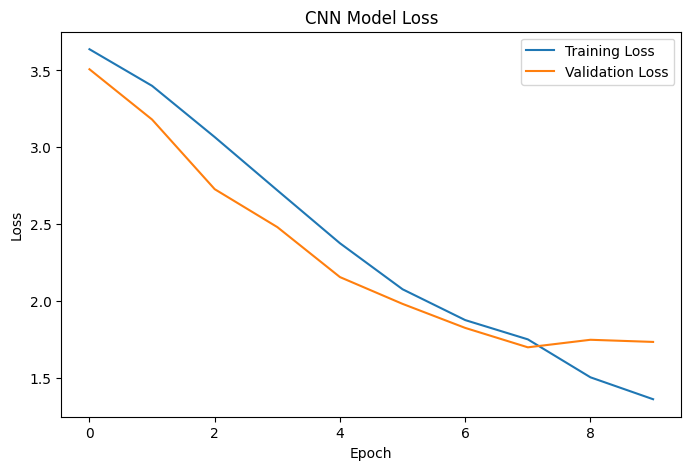

In [ ]:
# Plot loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CNN Model Loss")

plt.legend()
plt.show()

In [ ]:
# Select one image from the dataset

test_image = X_test[0]

test_label = Y_test[0]

print("Test image selected")
print("Image shape:", test_image.shape)

Test image selected
Image shape: (128, 128, 3)


In [ ]:
#  Predict disease

test_image_input = numpy.expand_dims(test_image, axis=0)

prediction = model.predict(test_image_input)

predicted_index = numpy.argmax(prediction[0])

predicted_class = class_names[predicted_index]

confidence = prediction[0][predicted_index] * 100

print("Predicted Disease:", predicted_class)
print("Confidence:", round(confidence, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
Predicted Disease: Tomato___Target_Spot
Confidence: 38.59 %


In [ ]:
#  Find actual disease

actual_index = numpy.argmax(test_label)

actual_class = class_names[actual_index]

print("Actual Disease:", actual_class)
print("Predicted Disease:", predicted_class)

Actual Disease: Tomato___healthy
Predicted Disease: Tomato___Target_Spot


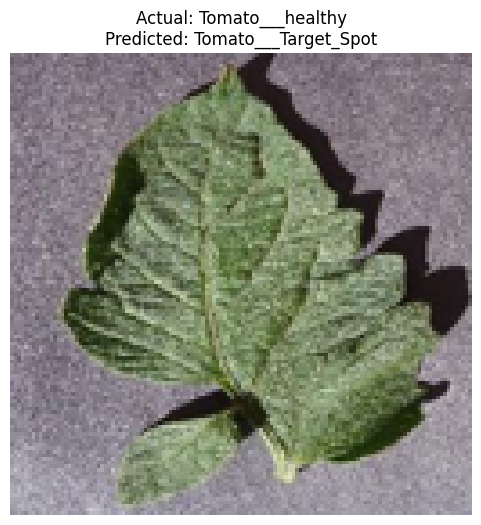

In [ ]:
#  Display test image

plt.figure(figsize=(6, 6))

plt.imshow(test_image)

plt.title(
    "Actual: " + actual_class +
    "\nPredicted: " + predicted_class
)

plt.axis("off")

plt.show()

In [ ]:
#  Prepare image for severity analysis

import cv2

# Convert image from 0-1 to 0-255
image_uint8 = (test_image * 255).astype(numpy.uint8)

# Convert RGB to HSV
hsv_image = cv2.cvtColor(image_uint8, cv2.COLOR_RGB2HSV)

print("Image prepared successfully")
print("Image shape:", image_uint8.shape)

Image prepared successfully
Image shape: (128, 128, 3)


In [ ]:
#  Detect leaf area

# Convert image to grayscale
gray_image = cv2.cvtColor(image_uint8, cv2.COLOR_RGB2GRAY)

# Threshold to separate leaf from background
_, leaf_mask = cv2.threshold(
    gray_image,
    50,
    255,
    cv2.THRESH_BINARY
)

print("Leaf area detected successfully")

Leaf area detected successfully


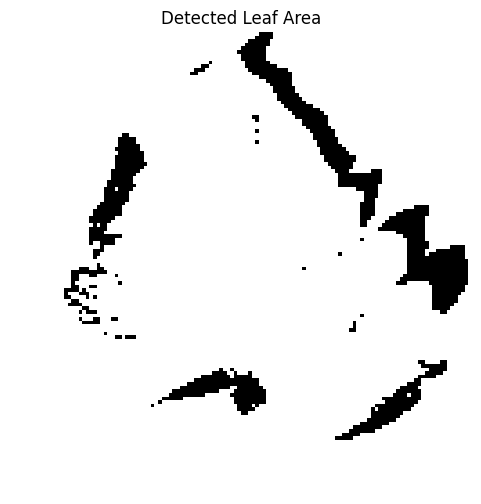

In [ ]:
# Display leaf mask

plt.figure(figsize=(6, 6))

plt.imshow(leaf_mask, cmap="gray")

plt.title("Detected Leaf Area")
plt.axis("off")

plt.show()

In [ ]:
# Calculate affected area percentage

# Count leaf pixels
leaf_pixels = numpy.sum(leaf_mask > 0)

# Create a mask for possible diseased areas
disease_mask = (
    (hsv_image[:, :, 0] > 5) &
    (hsv_image[:, :, 0] < 45) &
    (hsv_image[:, :, 1] > 40)
)

# Count disease pixels only inside the leaf
affected_pixels = numpy.sum(
    disease_mask & (leaf_mask > 0)
)

# Calculate percentage
if leaf_pixels > 0:
    affected_percentage = (
        affected_pixels / leaf_pixels
    ) * 100
else:
    affected_percentage = 0

print("Leaf Area Pixels:", leaf_pixels)
print("Affected Area Pixels:", affected_pixels)
print("Affected Area:", round(affected_percentage, 2), "%")

Leaf Area Pixels: 15082
Affected Area Pixels: 5292
Affected Area: 35.09 %


In [ ]:
#  Determine severity level

if affected_percentage < 20:
    severity = "Low"
elif affected_percentage < 50:
    severity = "Moderate"
else:
    severity = "Severe"

print("Affected Area:", round(affected_percentage, 2), "%")
print("Severity Level:", severity)

Affected Area: 35.09 %
Severity Level: Moderate


In [ ]:
# Display final plant disease result

print("=" * 45)
print("       PLANT DISEASE DETECTION RESULT")
print("=" * 45)

print("Disease       :", predicted_class)
print("Confidence    :", round(confidence, 2), "%")
print("Affected Area :", round(affected_percentage, 2), "%")
print("Severity      :", severity)

print("=" * 45)

       PLANT DISEASE DETECTION RESULT
Disease       : Tomato___Target_Spot
Confidence    : 38.59 %
Affected Area : 35.09 %
Severity      : Moderate


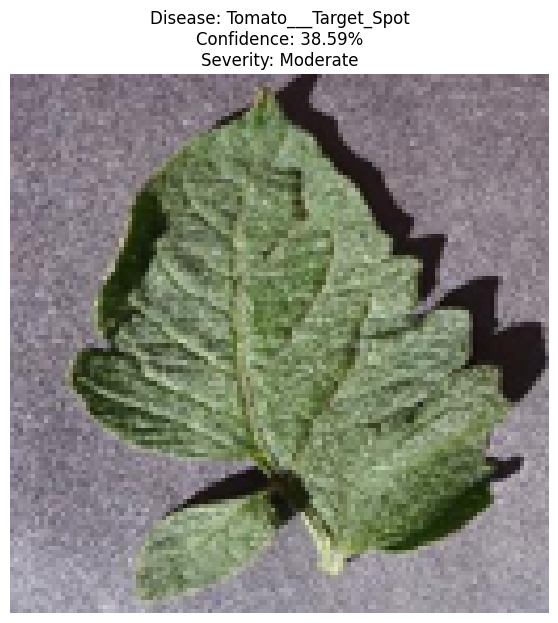

In [ ]:
# Display final result with image

plt.figure(figsize=(7, 7))

plt.imshow(test_image)

plt.title(
    "Disease: " + predicted_class +
    "\nConfidence: " + str(round(confidence, 2)) + "%" +
    "\nSeverity: " + severity
)

plt.axis("off")
plt.show()